In [1]:
import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt')
nltk.download('punkt_tab')

import matplotlib.pyplot as plt
import numpy as np
import re, string
from collections import Counter

import math
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, random_split
import random

torch.manual_seed(42)
random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\redcat\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\redcat\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Device: cuda


In [2]:
file_path = r"C:\Users\redcat\Desktop\ІАД\corpus-master\corpus-master\data\good\A_brovary_maiesh_pravo_znaty_Blok_Petra_Poroshenka_2015.txt"
with open(file_path, 'r', encoding='utf-8') as file:
        content = file.read()
print(content)

Блок Петра Порошенка «Солідарність» оприлюднив ймовірних кандидатів у депутати Броварської міськради

Блок Петра Порошенка «Солідарність» відкрив імена осіб, які можуть балотуватися від політсили на місцевих виборах. У партії зазначають, що перелік не остаточний, та пропонують свою команду до обговорення. Відповідний список та заяву з цього приводу в розпорядження «Маєш право знати» надав штаб цієї політсили.

У своїй заяві політсила зазначає про необхідність очистити владу міста від представників Партії регіонів. У партії нагадують про 5-річну історію боротьби із місцевою владою. Настав особливий час, до якого ми йшли не один рік. Час очистити наше місто від нечистих на руку представників Партії регіонів, які досі окупують наше місто. Час нарешті патріотичним Броварам отримати владу з патріотів нашого міста.

Майже п'ять років тому наша команда почала визвольну війну за Бровари, і зараз наш вирішальний бій з місцевою владою корупціонерів, дерибанщиків та шахраїв. Наша команда готова д

In [53]:
from pathlib import Path
directory_path = Path(r'C:\Users\redcat\Desktop\ІАД\corpus-master\corpus-master\data\good')
file_names = []

for entry in directory_path.iterdir():
    if entry.is_file():
        file_names.append(entry.name)
file_names[0]

'A_alumni.krok.edu.ua_Prokopenko_Vidrodzhennia_velotreku.txt'

In [55]:
file_path = rf"C:\Users\redcat\Desktop\ІАД\corpus-master\corpus-master\data\good\{file_names[0]}"
with open(file_path, 'r', encoding='utf-8') as file:
        content = file.read()
print(content)

Історія змін. Спільними зусиллями влада та громадськість врятували й повертають до життя Київський велотрек

Київський велотрек «Авангард» по вул. Богдана Хмельницького, 58-А, що збудований у 1913 році за ініціативи та кошти киян, відновлюється так само — силами громади і без фінансування з бюджету. А за відчутної підтримки влади реконструкція набирає обертів.

«Ще недавно велотрек існував тільки у мріях ентузіастів велоруху, а вже зараз він стрімко набирає реалістичних контурів, — радіє голова Шевченківської райдержадміністрації Олег Гаряга.
— Ми сподіваємося, що вже за півтора-два місяці на велотреку зможуть тренуватися спортсмени, а проводити змагання тут можна буде вже з наступної весни. Роботи на самому велотреку виконуються за кошти меценатів, і я вдячний усім небайдужим, хто сприяє розвитку цього проекту і своїми діями, щоденною працею, а не галасуванням, наближає його втілення».

БУЛО І Є

У 1991-му цей об'єкт був реконструйований і в 1998 році внесений до переліку пам'яток іст

In [57]:
all_text = ''
for i in range(100):
    temp_path = rf'C:\Users\redcat\Desktop\ІАД\corpus-master\corpus-master\data\good\{file_names[i]}'
    with open(temp_path, 'r', encoding='utf-8') as file:
        content = file.read()
    all_text = all_text + ' ' + content
print(len(all_text))
print(all_text[1000:2000])

349159
торії. А у 2006-му цей майданчик продали, незважаючи на протести громадськості. Захищати велотрек виходили сотні киян, і це були фактично перші масові протести городян проти свавілля забудовників у столиці. Поряд побудували висотку, яку досі не можуть ввести в експлуатацію, а на місці чаші велотреку забудовник планував звести офісний центр із підземним паркінгом.

Питання повернення міського велотреку для киян, і особливо шевченківців, було принциповим. У листопаді минулого року столична влада повернула Київський велотрек у власність громади міста — депутати Київради проголосували за розірвання договору оренди земельної ділянки, укладеного між Київрадою та підприємством «Велотрек Авангард», на якій розташовується велотрек.
 Блок Петра Порошенка «Солідарність» оприлюднив ймовірних кандидатів у депутати Броварської міськради

Блок Петра Порошенка «Солідарність» відкрив імена осіб, які можуть балотуватися від політсили на місцевих виборах. У партії зазначають, що перелік не остаточ

In [65]:
def split_into_sentences_regex(text):
    sentences = re.split(r'(?<=[.?!])\s+', text)
    return [s.strip() for s in sentences if s.strip()]
sentences = split_into_sentences_regex(all_text)
print(sentences[0], sentences[5])

Історія змін. — Ми сподіваємося, що вже за півтора-два місяці на велотреку зможуть тренуватися спортсмени, а проводити змагання тут можна буде вже з наступної весни.


In [67]:
def clean_text(text):
    text = text.lower()                                      
    text = re.sub(r"@\S+", " ", text)                         
    text = re.sub(r"http\S+", " ", text)                      
    text = re.sub(r"<.*?>", " ", text)                       
    text = re.sub(r"[^а-яієїґ\s]", " ", text)                     
    text = re.sub(f"[{re.escape(string.punctuation)}]", " ", text)  
    text = re.sub(r"\n", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text

In [69]:
cleaned_texts = [clean_text(ex) for ex in sentences]
tokens = [word_tokenize(t) for t in cleaned_texts]
print(len(cleaned_texts))

3176


In [71]:
cleaned_texts[0:5]

['історія змін ',
 'спільними зусиллями влада та громадськість врятували й повертають до життя київський велотрек київський велотрек авангард по вул ',
 'богдана хмельницького а що збудований у році за ініціативи та кошти киян відновлюється так само силами громади і без фінансування з бюджету ',
 'а за відчутної підтримки влади реконструкція набирає обертів ',
 ' ще недавно велотрек існував тільки у мріях ентузіастів велоруху а вже зараз він стрімко набирає реалістичних контурів радіє голова шевченківської райдержадміністрації олег гаряга ']

In [77]:
tokens[0][0]

'історія'

In [79]:
len(tokens)

3176

In [81]:
counter = Counter()
for tok_list in tokens:
    counter.update(tok_list)

In [83]:
vocab_size = len(counter)

print(f"Кількість унікальних слів у train-наборі: {vocab_size:,}")

Кількість унікальних слів у train-наборі: 16,187


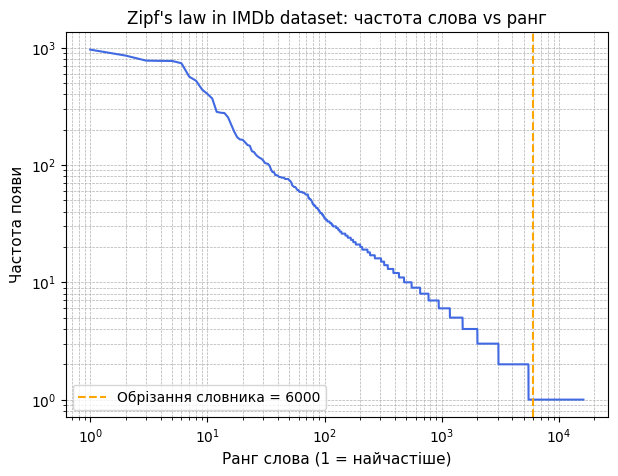

In [89]:
word_freqs = np.array(sorted(counter.values(), reverse=True))
ranks = np.arange(1, len(word_freqs) + 1)

plt.figure(figsize=(7, 5))
plt.loglog(ranks, word_freqs, color='royalblue')
plt.title("Zipf's law in IMDb dataset: частота слова vs ранг", fontsize=12)
plt.xlabel("Ранг слова (1 = найчастіше)", fontsize=11)
plt.ylabel("Частота появи", fontsize=11)
plt.grid(True, which="both", ls="--", lw=0.5)


MAX_VOCAB = 6000
plt.axvline(MAX_VOCAB, color='orange', linestyle='--', label=f'Обрізання словника = {MAX_VOCAB}')
plt.legend()

plt.show()

In [91]:
specials = ["[PAD]", "[UNK]", "[BOS]", "[EOS]"]
most_common = counter.most_common(MAX_VOCAB - len(specials))
itos = specials + [w for w, _ in most_common]
stoi = {w: i for i, w in enumerate(itos)}

PAD_IDX = stoi["[PAD]"]
UNK_IDX = stoi["[UNK]"]
BOS_IDX = stoi["[BOS]"]
EOS_IDX = stoi["[EOS]"]

print("Розмір словника:", len(stoi))
print("PAD:", PAD_IDX, "UNK:", UNK_IDX, "BOS:", BOS_IDX, "EOS:", EOS_IDX)

Розмір словника: 6000
PAD: 0 UNK: 1 BOS: 2 EOS: 3


In [93]:
len(cleaned_texts)

3176

In [95]:
MAX_LEN = 20

def encode_with_specials(tok_list):
    ids = [stoi.get(t, UNK_IDX) for t in tok_list]
    ids = ids[:MAX_LEN - 2]
    return [BOS_IDX] + ids + [EOS_IDX]

encoded_texts = [encode_with_specials(tok_list) for tok_list in tokens]
print(encoded_texts[0][:20])

[2, 248, 326, 3]


In [97]:
print(encoded_texts[1][:20])

[2, 3048, 3049, 205, 11, 1509, 3050, 15, 5498, 12, 98, 1176, 774, 1176, 774, 3051, 49, 1177, 3]


In [101]:
def pad_sequence(seq):
    seq = seq[:MAX_LEN]
    seq = seq + [PAD_IDX] * max(0, MAX_LEN - len(seq))
    return torch.tensor(seq, dtype=torch.long)
def make_lm_pair(seq):
    # seq вже містить [BOS ... EOS]
    inp = seq[:-1]   # [BOS ... останнє слово]
    tgt = seq[1:]    # [... EOS]
    return inp, tgt

In [103]:
pairs = [make_lm_pair(seq) for seq in encoded_texts]

X_in  = torch.stack([pad_sequence(inp) for inp, _ in pairs])
Y_tgt = torch.stack([pad_sequence(tgt) for _, tgt in pairs])

print(X_in.shape, Y_tgt.shape)   # [N, MAX_LEN]
print(X_in[0][:10])
print(Y_tgt[0][:10])

torch.Size([3176, 20]) torch.Size([3176, 20])
tensor([  2, 248, 326,   0,   0,   0,   0,   0,   0,   0])
tensor([248, 326,   3,   0,   0,   0,   0,   0,   0,   0])


In [105]:
print(X_in[1][:10])
print(Y_tgt[1][:10])

tensor([   2, 3048, 3049,  205,   11, 1509, 3050,   15, 5498,   12])
tensor([3048, 3049,  205,   11, 1509, 3050,   15, 5498,   12,   98])


In [145]:
dataset = TensorDataset(X_in, Y_tgt) # !!!

# розділяємо на train/val
VAL_FRAC = 0.2
val_sz = int(len(dataset) * VAL_FRAC)
train_sz = len(dataset) - val_sz
train_ds, val_ds = random_split(dataset, [train_sz, val_sz],
                                generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=128)

In [147]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)

    def forward(self, x):
        x = x + self.pe[:, : x.size(1)]
        return x

In [149]:
class TransformerDecoderLM(nn.Module):
    def __init__(
        self,
        vocab_size,
        emb_dim,
        pad_idx,
        n_heads=4,
        n_layers=2,
        dim_feedforward=256,
        dropout=0.1,
        max_len=5000,
    ):
        super().__init__()
        self.pad_idx = pad_idx
        self.emb_dim = emb_dim

        # Слово -> вектор
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=emb_dim,
            padding_idx=pad_idx,
        )

        # Позиційне кодування
        self.pos_encoding = PositionalEncoding(d_model=emb_dim, max_len=max_len)

        # Один шар декодера трансформера
        decoder_layer = nn.TransformerDecoderLayer(
            d_model=emb_dim,
            nhead=n_heads,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
        )

        # Стек із кількох шарів
        self.decoder = nn.TransformerDecoder(decoder_layer, num_layers=n_layers)

        # Проекція у простір словника
        self.fc_out = nn.Linear(emb_dim, vocab_size)

    def _generate_square_subsequent_mask(self, T, device):
        # каузальна маска: кожна позиція "бачить" тільки попередні слова
        mask = torch.triu(torch.ones(T, T, device=device), diagonal=1)
        mask = mask.masked_fill(mask == 1, float('-inf'))
        return mask
        
    def forward(self, x):
        # x: [B, T]
        emb = self.embedding(x)           # [B, T, D]
        emb = self.pos_encoding(emb)      # [B, T, D]

        B, T, D = emb.shape
        tgt_mask = self._generate_square_subsequent_mask(T, x.device)

        out = self.decoder(
            tgt=emb,
            memory=emb,
            tgt_mask=tgt_mask,
            tgt_key_padding_mask=(x == self.pad_idx),
            memory_key_padding_mask=(x == self.pad_idx),
        )                                 # [B, T, D]

        logits = self.fc_out(out)         # [B, T, V]
        return logits

In [151]:
model = TransformerDecoderLM(
    vocab_size=len(stoi),
    emb_dim=128,
    pad_idx=PAD_IDX,
    n_heads=4,
    n_layers=2,
    dim_feedforward=256,
    dropout=0.1,
    max_len=MAX_LEN,
).to(device)

In [153]:
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [155]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0

    for x, y in loader:
        x, y = x.to(device), y.to(device)      # x,y: [B, T]

        optimizer.zero_grad()
        logits = model(x)                      # [B, T, V]

        B, T, V = logits.shape
        loss = criterion(
            logits.view(B*T, V),
            y.view(B*T)
        )
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * B

    return running_loss / len(loader.dataset)

In [157]:
def evaluate_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)

            B, T, V = logits.shape
            loss = criterion(
                logits.view(B*T, V),
                y.view(B*T)
            )

            running_loss += loss.item() * B

    return running_loss / len(loader.dataset)

In [159]:
EPOCHS = 100

for ep in range(1, EPOCHS+1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss = evaluate_one_epoch(model, val_loader, criterion, device)
    print(f"Epoch {ep}/{EPOCHS} - loss: {train_loss:.4f} - val_loss: {val_loss:.4f}")

Epoch 1/100 - loss: 7.1590 - val_loss: 6.3955
Epoch 2/100 - loss: 6.1821 - val_loss: 6.2415
Epoch 3/100 - loss: 6.0478 - val_loss: 6.1587
Epoch 4/100 - loss: 5.9073 - val_loss: 6.0336
Epoch 5/100 - loss: 5.7067 - val_loss: 5.8496
Epoch 6/100 - loss: 5.4554 - val_loss: 5.6544
Epoch 7/100 - loss: 5.1471 - val_loss: 5.4416
Epoch 8/100 - loss: 4.8219 - val_loss: 5.2251
Epoch 9/100 - loss: 4.4755 - val_loss: 5.0155
Epoch 10/100 - loss: 4.1322 - val_loss: 4.8019
Epoch 11/100 - loss: 3.7816 - val_loss: 4.6002
Epoch 12/100 - loss: 3.4382 - val_loss: 4.4243
Epoch 13/100 - loss: 3.0972 - val_loss: 4.2134
Epoch 14/100 - loss: 2.7604 - val_loss: 4.0350
Epoch 15/100 - loss: 2.4358 - val_loss: 3.8623
Epoch 16/100 - loss: 2.1173 - val_loss: 3.7215
Epoch 17/100 - loss: 1.8226 - val_loss: 3.5510
Epoch 18/100 - loss: 1.5486 - val_loss: 3.3999
Epoch 19/100 - loss: 1.2873 - val_loss: 3.2715
Epoch 20/100 - loss: 1.0619 - val_loss: 3.1637
Epoch 21/100 - loss: 0.8639 - val_loss: 3.0576
Epoch 22/100 - loss: 0

In [183]:
itos = {i: w for w, i in stoi.items()}

def generate(model, start_text, max_new_tokens=20):
    model.eval()
    with torch.no_grad():
        # токенізуємо й чистимо
        tokens = word_tokenize(clean_text(start_text))
        ids = [BOS_IDX] + [stoi.get(t, UNK_IDX) for t in tokens]
        ids = ids[:MAX_LEN-1]  # щоб був запас для EOS

        seq = torch.tensor([ids], dtype=torch.long, device=device)

        for _ in range(max_new_tokens):
            logits = model(seq)              # [1, T, V]
            next_logits = logits[0, -1]      # остання позиція

            temperature = 2.0
            probs = torch.softmax(next_logits / temperature, dim=-1)


            next_idx = torch.multinomial(probs, num_samples=1).item()

            seq = torch.cat(
                [seq, torch.tensor([[next_idx]], device=device)],
                dim=1
            )

            if next_idx == EOS_IDX:
                break

        # перетворюємо назад у слова, ігноруємо PAD/BOS/EOS
        ids = seq[0].cpu().tolist()
        words = []
        for idx in ids:
            if idx in (PAD_IDX, BOS_IDX, EOS_IDX):
                continue
            words.append(itos.get(idx, ""))
        return " ".join(words)


print(generate(model, "ми прагнемо", max_new_tokens=10))

ми прагнемо формуватись отримав представлені
